Implementation of a basic transformer from start to finish. 
Code is mostly taken from CPSC4770 HW2 part 1

In [1]:
# Keep runtime deps in sync for this notebook environment.
%pip install -q transformers tokenizers

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch import Tensor
from typing import Tuple, List

import random
import math
import os
import time
import json
import numpy as np

# We'll set the random seeds for deterministic results.
SEED = 1

random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.enabled = False
torch.backends.cudnn.deterministic = True

class Placeholder:
    @property
    def DO(self):
        raise NotImplementedError("You haven't yet implemented this part of the assignment yet")

TO = Placeholder()

Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print("Pytorch version is: ", torch.__version__)
print("You are using: ", DEVICE)

Pytorch version is:  2.7.0
You are using:  mps


In [3]:
# The first thing we want to do is tokenization

from transformers import GPT2Tokenizer

# Load pre-trained model tokenizer (vocabulary)
# Basically GPT2 knows how to split text into tokens. When we create a tokenizer object, it downloads the vocabulary and the rules for tokenization.
# We can then use this tokenizer to convert text into token IDs that the model can understand.
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')

# this is basically the text we want to tokenize
text = "This adaptation of the enigmatic novel by Liane Moriarty is supremely watchable but flawed."

# we can use tokenizer.encode to convert text to token IDs. I also print the decoded tokens and how the tokenizer
# actually converts the ids back to tokens (when we use convert_ids_to_tokens, we get the tokenizer’s internal token representation)
tokens_ids = tokenizer.encode(text)
for token_id in tokens_ids:
    print(token_id, tokenizer.decode(token_id), tokenizer.convert_ids_to_tokens(token_id))


/Users/timli/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


1212 This This
16711  adaptation Ġadaptation
286  of Ġof
262  the Ġthe
48584  enigmatic Ġenigmatic
5337  novel Ġnovel
416  by Ġby
406  L ĠL
46470 iane iane
32709  Mori ĠMori
25494 arty arty
318  is Ġis
17700  supreme Ġsupreme
306 ly ly
2342  watch Ġwatch
540 able able
475  but Ġbut
19556  flawed Ġflawed
13 . .


In [4]:
# Now we want to implement the embedding layer
#
# So why do we embed?
# The language model can not work directly with words like: ["This", "movie", "is", "great"] or even token IDs like [1212, 345, 6789].
# We need to convert these token IDs into dense vectors that capture the semantic meaning of the tokens. This is what the embedding layer does.

import torch
import torch.nn as nn
from torch import Tensor

class Embedding(nn.Module):
    def __init__(self, vocab_size: int, d_model: int):
        super(Embedding, self).__init__()
        # here we basically say let's say we have 50,000 possible tokens in our vocabulary -> we map each token to a d_model dimensional vector.
        # wte stands for "word token embedding"
        self.wte = nn.Embedding(vocab_size, d_model)

    # this defines what happens when data is passed through the layer
    # let's say we have an input x = torch.tensor([10, 25, 7, 91]) -> here we have a sequence length of 4
    # after passing it through the forward function we get (sequence_length, d_model)
    def forward(self, x: Tensor) -> Tensor:
        return self.wte(x)

# tests
vocab_size = 10
d_model = 16

embedding = Embedding(vocab_size, d_model)
x = torch.tensor([1, 2, 3, 4])
output = embedding(x)
assert output.shape == (4, d_model)


In [5]:
# Now let's look at our positional embedding layers

# The goal of positional embedding is to give the model information about the position of each token in the sequence.
# This is crucial because the transformer architecture does not have any inherent notion of order (unlike RNNs or CNNs).

class PositionalEmbeddings(nn.Module):
    def __init__(self, d_model: int, max_len: int):
        super().__init__()
        # here we create an embedding layer that maps each position (from 0 to max_len-1) to a d_model dimensional vector
        # basically row 0 will be the positional embedding for position 0, etc.
        # if max_len is 512, we will have 512 positional embeddings, each of size d_model
        self.positional_embeddings = nn.Embedding(max_len, d_model)


    def forward(self, x: Tensor) -> Tensor:
        # here we assume x is a tensor of shape (sequence_length,) containing the positions of the tokens in the sequence
        # when we pass x through the positional embedding layer, we get (sequence_length, d_model)
        return self.positional_embeddings(x)



# tests

d_model = 16
max_len = 64
positional_embeddings = PositionalEmbeddings(d_model, max_len)
x = torch.tensor([1, 2, 3, 4])
output = positional_embeddings(x)
assert output.shape == (4, d_model)


# The code above is learned positional embeddings, which means that the model will learn a unique embedding for each position during training.
# However, in the original transformer paper, they used sinusoidal positional embeddings, which are fixed and do not require learning. Let's implement sinusoidal positional embeddings as well.
class PositionalEmbeddings2(nn.Module):
    def __init__(self, d_model: int, max_len: int):
        super().__init__()
        # here we create a matrix of shape (max_len, d_model) where each row corresponds to the positional embedding for that position
        pe = torch.zeros(max_len, d_model)
        # now we create the positions tensor which is [[0], [1], [2], ..., [max_len-1]]
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)

        div_term = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float) * (-math.log(10000.0) / d_model))
        # we fill the even indices of the positional embedding with sine functions and the odd indices with cosine functions
        # this means that for position i, the embedding will have sin(i / 10000^(2j/d_model)) at even indices and cos(i / 10000^(2j/d_model)) at odd indices
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer("pe", pe)
    # the input x is a tensor of shape (sequence_length, ) containing the positions of the tokens in the sequence
    def forward(self, x: Tensor) -> Tensor:
        # after passing x through the forward function, we get (sequence_length, d_model) where each row corresponds to the positional embedding for that position
        return self.pe[x]


In [6]:
# now we can combine the token and positional embeddings

class TokenEmbedder(nn.Module):
    def __init__(self, vocab_size: int, d_model: int, max_len: int):
        super(TokenEmbedder, self).__init__()
        self.token_embedding = Embedding(vocab_size, d_model)
        self.positional_embedding = PositionalEmbeddings(d_model, max_len)

    def forward(self, x: Tensor) -> Tensor:
        # add the token embeddings and positional embeddings together
        pos = torch.arange(0, x.shape[1], dtype=torch.long, device=x.device) # shape: [sequence length]
        # here we can just add the token embeddings and positional embeddings together because they have the same shape (sequence_length, d_model)
        return self.token_embedding(x) + self.positional_embedding(pos)

# testing
# test the whole input pipeline

sample_texts = ["This adaptation of the enigmatic novel by Liane Moriarty is supremely watchable but flawed.",
                "The story is a bit of a slow burn, but the performances are top-notch and the ending is worth the wait."]

# encode the text
vocab_size = tokenizer.vocab_size
d_model = 64

# return_tensors="pt" returns pytorch tensors directly. truncation and padding are used to ensure the input length is the same
tokenizer.pad_token = tokenizer.eos_token
token_ids = tokenizer(sample_texts, return_tensors="pt", max_length=64, padding="longest", truncation=True)['input_ids']

token_embedder = TokenEmbedder(vocab_size=tokenizer.vocab_size, d_model=768, max_len=64)

# pass the token_ids to the token_embedder
output = token_embedder(token_ids)

output.shape

torch.Size([2, 26, 768])

Now that we have implemented the input pipeline we can move on to the transformer model architecture.

The first thing we need to do is implement the QKV projections.

In the transformer architecture, we have three matrices: Query (Q), Key (K), and Value (V).
These are linear projections of the input embeddings. The idea is that for each token in the sequence, we want to compute a query vector, a key vector, and a value vector.
The attention mechanism will then use these vectors to compute the attention scores and the weighted sum of the values.


What is the query vector? (Q)
Represents what information you are currently looking for.
For a specific word you’re processing, the Query vector asks, “What other words are relevant to understanding this word?”

What is the key vector? (K)
Key (K): Represents the “label” or identifier for the information available.
Each word in the sequence has a Key vector essentially saying, “Here’s the kind of information I hold.”

What is the value vector? (V)
Value (V): Represents the actual information content.
Each word also has a Value vector, which is the information to be retrieved if that word is deemed relevant.


In [7]:

import torch
import torch.nn as nn

class QKVProjection(nn.Module):
    def __init__(self, d_model, num_heads, d_k):
        super(QKVProjection, self).__init__()
        assert num_heads * d_k == d_model, "d_model must be equal to num_heads * d_k"
        self.num_heads = num_heads
        self.d_k = d_k

        # we create three linear layers for Q, K, and V.
        # Here we are projecting the input from d_model to num_heads * d_k, which is the total dimension for all heads combined.
        self.q_linear = nn.Linear(d_model, num_heads * d_k)
        self.k_linear = nn.Linear(d_model, num_heads * d_k)
        self.v_linear = nn.Linear(d_model, num_heads * d_k)

    def forward(self, X):
        batch_size, seq_length, d_model = X.shape

        # here we apply the linear layers to get Q, K, V of shape (batch_size, seq_length, num_heads * d_k)
        # we are basically applying the learned linear transformation in self.q_linear to each token embedding which would be like a singular vector of size d_model
        Q = self.q_linear(X)
        K = self.k_linear(X)
        V = self.v_linear(X)

        # now since we need to do multi-head attention, we need to reshape and transpose Q, K, V so that we can do batched attention
        # after the linear layer, we have shape (batch_size, seq_length, num_heads * d_k) -> and we want to get (batch_size, num_heads, seq_length, d_k)

        # We can apply the following transformations:
        # 1. VIEW: split the last dim into (num_heads, d_k) -> (batch, seq, num_heads, d_k).
        # 2. TRANSPOSE(1, 2): swap seq and num_heads -> (batch, num_heads, seq, d_k).
        #    This way each "head" is (seq, d_k), and we can do batched attention:
        #    scores (batch, num_heads, seq, seq) @ V (batch, num_heads, seq, d_k) -> (batch, num_heads, seq, d_k).
        # Target shape for Q, K, V: (batch_size, num_heads, seq_length, d_k).
        Q = Q.view(batch_size, seq_length, self.num_heads, self.d_k).transpose(1, 2)
        K = K.view(batch_size, seq_length, self.num_heads, self.d_k).transpose(1, 2)
        V = V.view(batch_size, seq_length, self.num_heads, self.d_k).transpose(1, 2)

        return Q, K, V

# tests
d_model = 512  # Embedding size
num_heads = 8  # Number of attention heads
d_k = 64  # Dimension per head (num_heads * d_k must be d_model)

batch_size = 2
seq_length = 10

# Random input tensor
X = torch.rand(batch_size, seq_length, d_model)

# Instantiate and apply QKVProjection
qkv_projection = QKVProjection(d_model, num_heads, d_k)
Q, K, V = qkv_projection(X)

print(Q.shape, K.shape, V.shape)

torch.Size([2, 8, 10, 64]) torch.Size([2, 8, 10, 64]) torch.Size([2, 8, 10, 64])


The next part is multi-head self-attention. This allows the model to weigh the importance of different tokens in the input sequence when computing the output for each token. The main parameters of this layer are the projection matrices $W_Q$, $W_K$, $W_V$ and we have H heads. 

So why do we even use multi-headed self-attention?
Imagine trying to understand a complex sentence. You might simultaneously pay attention to its grammatical structure, the semantic meaning of words, and perhaps coreference (which pronouns refer to which nouns). A single attention mechanism might struggle to focus on all these aspects at once. We can use many different heads to keep track of each of these aspects.

In [8]:
import math
import torch.nn.functional as F

# Large negative value for masking (more numerically stable than -inf, especially on MPS/Metal)
MASK_VALUE = -1e9

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, d_k, attn_pdrop=None):

        # this is initializing the multi-headed attention module as a big picture

        # 1. project input X into Q, K, V
        # 2. split into multiple heads
        # 3. compute attention for each head
        # 4. combine the heads back together
        # 5. apply one final linear layer

        super(MultiHeadAttention, self).__init__()

        assert num_heads * d_k == d_model, "d_model must be equal to num_heads * d_k"

        self.num_heads = num_heads
        self.d_k = d_k
        # here attn_pdrop is the dropout probability for the attention weights.
        # We will apply dropout to the attention weights after softmax to prevent overfitting.
        self.attn_pdrop = attn_pdrop

        # Use the improved QKVProjection
        self.qkv_projection = QKVProjection(d_model, num_heads, d_k)

        # Final output projection
        self.out_linear = nn.Linear(d_model, d_model)

    def forward(self, X, causal_mask=False, attention_mask=None):
        '''
        Args:
            X (torch.Tensor): Input tensor of shape (batch_size, seq_length, d_model).
            causal_mask (bool): If True, apply a causal mask to prevent attending to future tokens.
            attention_mask (torch.Tensor, optional): Padding mask of shape (batch_size, seq_length).
                Contains 1 for real tokens and 0 for padding tokens.
        Returns:
            Tuple[torch.Tensor, torch.Tensor]: A tuple containing:
                - attention_weights (torch.Tensor): Attention weights of shape (batch_size, num_heads, seq_length, seq_length).
                - output (torch.Tensor): Output tensor of shape (batch_size, seq_length, d_model).
        '''
        # Generate Q, K, V using the projection module
        Q, K, V = self.qkv_projection(X)
        batch_size, num_heads, seq_length, d_k = Q.shape

        # Compute scaled dot-product attention for the raw_scores:
        # a) Compute the raw attention scores using the dot product between Q and K.
        # b) Scale the scores by dividing by sqrt(d_k).
        raw_scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

        # Apply causal mask if causal_mask is True
        # Create an upper triangular matrix of ones using torch.triu(..., diagonal=1)
        # and use masked_fill to set future positions to MASK_VALUE BEFORE applying softmax.

        # Why do we use a casual mask? In autoregressive language modeling, we want to prevent the model from attending to future tokens that it shouldn't have access to during training.
        # The causal mask ensures that each token can only attend to itself and previous tokens, not future ones.

        if causal_mask:
            causal = torch.triu(torch.ones(seq_length, seq_length, device=X.device), diagonal=1).bool()
            raw_scores = raw_scores.masked_fill(causal, MASK_VALUE)

        # Apply the padding attention mask (attention_mask) to the scores
        # The attention_mask has shape (batch_size, seq_length) with 1 for real tokens and 0 for padding.
        # You need to:
        #   1. Identify padding positions (where attention_mask == 0)
        #   2. Expand the mask to shape (batch_size, 1, 1, seq_length) so it broadcasts over heads and query positions
        #   3. Use masked_fill to set those positions to MASK_VALUE BEFORE softmax

        # What are padding tokens? In NLP tasks, we will often have sentences with different lengths. Therefore, we need to
        # pad shorter sentences with special padding tokens to ensure that all sentences in a batch have the same length.
        # The attention_mask helps the model ignore these padding tokens during attention computation.
        if attention_mask is not None:
            padding_positions = (attention_mask == 0)
            padding_mask = padding_positions.view(batch_size, 1, 1, seq_length)
            raw_scores = raw_scores.masked_fill(padding_mask, MASK_VALUE)

        # Apply softmax to get attention weights
        attention_weights = F.softmax(raw_scores, dim =-1)

        # Apply dropout to the attention weights only during training

        # Why do we apply dropout to the attention weights?
        # Dropout is a regularization technique that helps prevent overfitting by randomly setting some of the attention weights to zero during training.
        # This encourages the model to not rely too heavily on any single token and promotes better generalization.
        if self.attn_pdrop is not None and self.training:
            attention_weights = F.dropout(attention_weights, p=self.attn_pdrop, training=self.training)

        # the query says: “What am I looking for?”
        # the keys say: “What kind of information does each token have?”
        # the attention weights decide: “Which tokens are relevant, and by how much?”
        # the values are the actual information to retrieve
        # the context vector is the final “retrieved information”
        context = torch.matmul(attention_weights, V)

        # Compute the output vector.
        # we need to reshape the context tensor to match the original shape of X.
        context = context.transpose(1, 2).contiguous().view(batch_size, seq_length, num_heads * d_k)
        output = self.out_linear(context)

        return attention_weights, output

# Example usage:
d_model = 512  # Embedding size
num_heads = 8  # Number of attention heads
d_k = 64  # Dimension per head (num_heads * d_k must be d_model)

batch_size = 2
seq_length = 10

# Random input tensor
X = torch.rand(batch_size, seq_length, d_model)

# Instantiate and apply Multi-Head Attention
multi_head_attn = MultiHeadAttention(d_model, num_heads, d_k, attn_pdrop=0.0)
_, C = multi_head_attn(X)

print(C.shape)  # Expected: (batch_size, seq_length, d_model)


torch.Size([2, 10, 512])


In [9]:

# ----------- Unit tests ---------------

import unittest
import torch

class TestMultiHeadAttention(unittest.TestCase):
    def setUp(self):
        self.d_model = 512
        self.num_heads = 8
        self.d_k = 64
        self.batch_size = 2
        self.seq_length = 10
        torch.manual_seed(42)
        self.multi_head_attn = MultiHeadAttention(self.d_model, self.num_heads, self.d_k)
        self.X = torch.rand(self.batch_size, self.seq_length, self.d_model, requires_grad=True)

    def test_output_shape(self):
        _, output = self.multi_head_attn(self.X)
        expected_shape = (self.batch_size, self.seq_length, self.d_model)
        self.assertEqual(output.shape, expected_shape, f"Expected shape {expected_shape}, but got {output.shape}")

    def test_deterministic_behavior(self):
        torch.manual_seed(42)
        _, output1 = self.multi_head_attn(self.X)
        torch.manual_seed(42)
        _, output2 = self.multi_head_attn(self.X)
        self.assertTrue(torch.allclose(output1, output2, atol=1e-6), "MultiHeadAttention is not deterministic!")

    def test_gradient_computation(self):
        """Ensure gradients are computed properly."""
        _, output = self.multi_head_attn(self.X)
        loss = output.sum()  # Simple loss function
        loss.backward()

        self.assertIsNotNone(self.X.grad, "Gradients were not computed for input!")
        self.assertGreater(self.X.grad.abs().sum().item(), 0, "Gradient sum is zero!")

    def test_attention_softmax(self):
        """Ensure that the attention scores sum up to ~1."""
        attention_weights, _ = self.multi_head_attn(X)

        # Sum of softmax probabilities along last dimension should be close to 1
        attention_sum = attention_weights.sum(dim=-1)
        ones = torch.ones_like(attention_sum)

        self.assertTrue(torch.allclose(attention_sum, ones, atol=1e-6), "Attention weights do not sum to 1!")

    def test_known_computation(self):
        d_model = 4
        num_heads = 1
        d_k = 4
        seq_length = 3
        batch_size = 1
        multi_head_attn = MultiHeadAttention(d_model, num_heads, d_k)
        with torch.no_grad():
            # For Q, K, V projections
            for linear in [multi_head_attn.qkv_projection.q_linear,
                           multi_head_attn.qkv_projection.k_linear,
                           multi_head_attn.qkv_projection.v_linear,
                           multi_head_attn.out_linear]:
                linear.weight.copy_(torch.eye(d_model))
                if linear.bias is not None:
                    linear.bias.zero_()
        X_known = torch.ones(batch_size, seq_length, d_model)
        attention_weights, output = multi_head_attn(X_known)
        expected_output = torch.ones(batch_size, seq_length, d_model)
        self.assertTrue(torch.allclose(output, expected_output, atol=1e-6),
                        f"Expected output {expected_output}, but got {output}")

    def test_padding_mask(self):
        """Ensure that padding mask prevents attending to padded positions."""
        d_model = 4
        num_heads = 1
        d_k = 4
        seq_length = 4
        batch_size = 1

        multi_head_attn = MultiHeadAttention(d_model, num_heads, d_k)
        X_test = torch.rand(batch_size, seq_length, d_model)
        # Mask out last 2 positions (padding)
        attn_mask = torch.tensor([[1, 1, 0, 0]])
        attention_weights, _ = multi_head_attn(X_test, attention_mask=attn_mask)
        # Attention weights to padded positions should be ~0
        self.assertTrue(
            torch.allclose(attention_weights[:, :, :, 2:], torch.zeros_like(attention_weights[:, :, :, 2:]), atol=1e-6),
            "Attention weights to padded positions should be zero!"
        )

unittest.main(argv=[''], exit=False)

./Users/timli/miniconda3/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
.....
----------------------------------------------------------------------
Ran 6 tests in 0.554s

OK


Now let's implement the feed forward network and the layer normalization.

# Why do we do Layer Normalization?

Deep neural networks can suffer from unstable training dynamics, where the distribution of activations in intermediate layers shifts significantly during training (internal covariate shift). Normalization techniques help mitigate this. While Batch Normalization is common in computer vision, Layer Normalization is often preferred in Transformers and NLP.

Concept: Layer Normalization works by normalizing the features across the embedding dimension for each token independently within a layer. It calculates the mean and standard deviation for all features of a single token and uses them to normalize that token’s feature vector. Unlike Batch Norm, its calculations don’t depend on the batch size, making it more stable for variable sequence lengths common in NLP.

# What is the feed forward network?

After the attention mechanism processes the relationships between tokens, each position’s resulting vector is passed through a Position-wise Feed-Forward Network (FFN) independently. This provides additional non-linear processing capacity to the model.

Here we can just see that it is a two layer neural network with ReLU activation and dropout.

In [10]:
# Here we have the feed forward class, the input will be of shape (batch_size, seq_length, d_model) and represents the output of the multi-head attention layer.
# so after attention, the token will have a context-aware vector meaning. For example, "this word is probably a verb related to a past action"
# The feed-forward network can further transform that representation into something more useful for the next layer.
class FeedForward(nn.Module):
    def __init__(self, d_model: int, d_ff: int, dropout: float):
        super(FeedForward, self).__init__()

        self.fc1 = nn.Linear(d_model, d_ff)
        self.activation = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(d_ff, d_model)


    def forward(self, x: Tensor) -> Tensor:
        x = self.fc1(x)
        x = self.activation(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Here we have the layer normalization class, the input will also be of shape (batch_size, seq_length, d_model)
# basically for each token vector, layer normalization will calculate the mean, variance, normalize it so it has mean 0 and variance 1,
# and then apply a learned scale (gamma) and shift (beta) to allow the model to restore the original distribution if needed.

class LayerNorm(nn.Module):
    def __init__(self, hidden_size, eps: float):
        super(LayerNorm, self).__init__()
        # learnable scale vector of shape (hidden_size,)
        self.gamma = nn.Parameter(torch.ones(hidden_size))
        # learnable shift vector of shape (hidden_size,)
        self.beta = nn.Parameter(torch.zeros(hidden_size))
        # epsilon is a small constant added to the variance to prevent division by zero during normalization.
        self.eps = eps

    # let's say x is (2, 10, 512), we have 2 sequences, each with 10 tokens, and each token is represented by a 512-dimensional vector.
    # we will just apply layer normalization to each token vector independently, so we will compute the mean and variance across the last dimension (the hidden size dimension) for each token vector.
    def forward(self, x: Tensor) -> Tensor:
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, unbiased=False, keepdim=True)
        normed = (x - mean) / torch.sqrt(var + self.eps)

        return normed * self.gamma + self.beta

We are building a decoder-only architecture transformer so let's build the transformer block. 

In [11]:
# This uses your previous implementation of the previous blocks.
# Remember that we need to use the MultiHeadAttention, FeedForward, and LayerNorm modules that you implemented earlier

class TransformerBlock(nn.Module):
    def __init__(self, d_model: int, num_heads: int, attn_pdrop: float, dropout: float, d_ff: int, eps: float):
        super(TransformerBlock, self).__init__()
        d_k = d_model // num_heads

        # this creates the multi-head self-attention layer.
        # we first compute Q, K, V, apply scaled dot-product attention, optionally apply a causal mask, and finally return the attended output
        # Because this is self-attention, the same input x is used to make Q, K, and V.
        self.attn = MultiHeadAttention(d_model, num_heads, d_k, attn_pdrop=attn_pdrop)
        # feed-forward network will just process each token after the attention step
        self.ff = FeedForward(d_model, d_ff, dropout)
        # two layer norms, one before the attention and one before the feed-forward network
        self.ln1 = LayerNorm(d_model, eps)
        self.ln2 = LayerNorm(d_model, eps)
        # dropout applied after attention and feed-forward layers to prevent overfitting
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: Tensor, causal_mask: bool, attention_mask=None) -> Tensor:
        '''
        Perform the forward pass of the transformer block.
        Args:
            x (Tensor): Input tensor with shape (batch_size, seq_length, d_model).
            causal_mask (bool): If True, apply a causal mask in the self-attention layer
                                (useful for decoder self-attention to prevent attending to future tokens).
            attention_mask (Tensor, optional): Padding mask of shape (batch_size, seq_length).
                Contains 1 for real tokens and 0 for padding tokens. Pass this to MultiHeadAttention.
        Returns:
            Tensor: The output of the transformer block with shape (batch_size, seq_length, d_model).
        '''
        # first normalize the input x before the attention layer
        x_norm = self.ln1(x)
        # then we pass the normalized input through the multi-head attention layer, which returns the attention weights and the attended output
        attn_weights, attn_out = self.attn(x_norm, causal_mask=causal_mask,attention_mask=attention_mask)
        # we add the attended output back to the original input x (residual connection) and apply dropout
        # new representation = old representation + attention update
        x = x + self.dropout(attn_out)
        # now we normalize again before the feed-forward network
        x_norm = self.ln2(x)
        # we pass the normalized output through the feed-forward network, which applies two linear transformations with a ReLU activation in between
        ff_out = self.ff(x_norm)
        # finally, we add the feed-forward output back to x (residual connection) and apply dropout
        x = x + self.dropout(ff_out)

        return x

Now we stack N of these transformer blocks together to implement the transformer stack. 

In [12]:
class TransformerStack(nn.Module):
    def __init__(self, num_layers: int, d_model: int, num_heads: int, attn_pdrop: float, dropout: float, d_ff: int, eps: float):
        '''
        A stack of Transformer blocks that processes input sequentially through multiple layers.
        This architecture allows for deep hierarchical processing of input sequences.

        Architecture:
            Input → TransformerBlock₁ → TransformerBlock₂ → ... → TransformerBlockₙ → Output
        '''
        super(TransformerStack, self).__init__()

        # here we create a list of transformer blocks. Each block will take the output of the previous block as its input.
        self.layers = nn.ModuleList()
        # we loop through the number of layers and create a new TransformerBlock for each layer, passing in the same hyperparameters for each block.
        for _ in range(num_layers):
            self.layers.append(TransformerBlock(d_model, num_heads, attn_pdrop, dropout, d_ff, eps))

    def forward(self, x: Tensor, causal_mask: bool, attention_mask=None) -> Tensor:
        '''
        Process input through all transformer blocks sequentially.

        Implementation steps:
        1. Iterate through each layer in the stack
        2. Pass the output of each layer as input to the next layer
        3. Maintain the causal mask and attention_mask throughout if specified
        Args:
            x (Tensor): Input tensor of shape (batch_size, seq_length, d_model)
            causal_mask (bool): If True, apply causal masking in all attention layers
            attention_mask (Tensor, optional): Padding mask of shape (batch_size, seq_length).
                Pass this through to each TransformerBlock.
        Returns:
            Tensor: Processed output of shape (batch_size, seq_length, d_model)
        '''
        for layer in self.layers:
            x = layer(x, causal_mask=causal_mask, attention_mask=attention_mask)
        return x

Now we can combine everything to code up our entire transformer model.

In [13]:
class TransformerModel(nn.Module):
    '''
    Architecture:
        Input Tokens → Token Embeddings → Transformer Stack → Language Model Head → Output Logits
    '''
    def __init__(self, vocab_size: int, d_model: int, num_heads: int, attn_pdrop: float, dropout: float, d_ff: int, max_len: int, num_layers: int, eps: float):
        super(TransformerModel, self).__init__()

        # You should create the TokenEmbedder and TransformerStack modules
        # At the end, you should add a linear layer to convert the transformer output to the vocabulary size
        # this is the language model head which allows us to predict the next token in the sequence

        self.embedder = TokenEmbedder(vocab_size, d_model, max_len)
        self.transformer_stack = TransformerStack(num_layers, d_model, num_heads, attn_pdrop, dropout, d_ff, eps)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)

    def forward(self, x: Tensor, causal_mask: bool, attention_mask=None) -> Tensor:
        '''
        Forward pass of the transformer model.

        Args:
            x (Tensor): Input token IDs of shape (batch_size, seq_length).
            causal_mask (bool): If True, apply causal masking in attention layers.
            attention_mask (Tensor, optional): Padding mask of shape (batch_size, seq_length).
                Contains 1 for real tokens and 0 for padding tokens. Pass this to TransformerStack.

        Returns:
            Tensor: Logits of shape (batch_size, seq_length, vocab_size).
        '''
        h = self.embedder(x)
        h = self.transformer_stack(h, causal_mask=causal_mask, attention_mask=attention_mask)
        logits = self.lm_head(h)
        return logits

Now we can try to test our model.

In [14]:
# hyperparameters

vocab_size = tokenizer.vocab_size
d_model = 768
num_heads = 12
attn_pdrop = 0.1
dropout = 0.1
# d_ff is the dimension of the feed-forward network, which is typically larger than d_model to allow for more complex transformations.
# In the original transformer paper, they used d_ff = 4 * d_model, so if d_model is 768, we can set d_ff to 3072.
# This means that the feed-forward network will have an intermediate layer of size 3072 before projecting back down to d_model.
d_ff = 3072
max_len = 20
num_layers = 12
eps = 1e-6

# create the model
model = TransformerModel(vocab_size, d_model, num_heads, attn_pdrop, dropout, d_ff, max_len, num_layers, eps)

encoded = tokenizer(sample_texts, return_tensors="pt", max_length=max_len, padding="longest", truncation=True)
token_ids = encoded['input_ids']
attention_mask = encoded['attention_mask']
output = model(token_ids, causal_mask=True, attention_mask=attention_mask)

In [ ]:
# loading the dataset

try:
    from datasets import load_dataset
except ImportError as exc:
    msg = str(exc)
    if "BucketNotFoundError" in msg:
        raise RuntimeError(
            "Your notebook kernel still has stale Hugging Face modules loaded from the earlier `%pip` upgrade. "
            "Restart the kernel, then rerun the notebook from the top without reinstalling packages in this cell."
        ) from exc
    raise ImportError(
        "The `datasets` package is not available in this notebook kernel. "
        "Install it in a separate cell with `%pip install datasets`, restart the kernel, and rerun the notebook."
    ) from exc

try:
    # Load a small language modeling dataset
    wiki_dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="train")

    # Filter out empty lines and very short texts
    train_texts = [x['text'] for x in wiki_dataset if len(x['text'].strip()) > 50]
    print(f"Number of training texts: {len(train_texts)}")
    print(f"Example: {train_texts[0][:200]}")
except Exception as exc:
    print(f"Could not download WikiText ({exc}). Falling back to the local sample texts instead.")
    train_texts = [text for text in sample_texts if len(text.strip()) > 0]
    print(f"Number of fallback texts: {len(train_texts)}")
    print(f"Example: {train_texts[0][:200]}")


Generating validation split: 100%|██████████| 3760/3760 [00:00<00:00, 69883.38 examples/s]


Number of training texts: 16184
Example:  Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ p


In [19]:
# Data loading code
# DO NOT EDIT THIS CELL

from torch.utils.data import Dataset, DataLoader

tokenizer.pad_token = tokenizer.eos_token

class TextDataset(Dataset):
    """Simple dataset that wraps a list of text strings."""
    def __init__(self, texts):
        self.texts = texts

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.texts[idx]

seq_len = 64
batch_size = 8

def collate_fn(batch_texts):
    # The collate function prepares each batch for model input by tokenizing and padding all texts
    # in the batch to a fixed maximum length. It returns tensors of input token ids and attention masks,
    # ensuring consistent batch shapes and properly masked positions for the transformer.
    """Tokenize and pad a batch of texts."""
    encoded = tokenizer(batch_texts, return_tensors='pt', max_length=seq_len,
                        padding='max_length', truncation=True)
    return encoded['input_ids'], encoded['attention_mask']

train_dataset = TextDataset(train_texts)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)

# train_loader is an iterable that yields batches of tokenized input_ids and attention_masks, which can be directly fed into the transformer model during training.
# we can print what exactly is in train_loader to see how the data is structured
for batch in train_loader:
    input_ids, attention_masks = batch
    print(f"Batch input_ids shape: {input_ids.shape}, Batch attention_masks shape: {attention_masks.shape}")
    print(f"Example input_ids: {input_ids[0][:10]}, Example attention_mask: {attention_masks[0][:10]}")
    break
print(f"Dataset size: {len(train_dataset)}, Number of batches per epoch: {len(train_loader)}")

Batch input_ids shape: torch.Size([8, 64]), Batch attention_masks shape: torch.Size([8, 64])
Example input_ids: tensor([  383,  1708,  3084,  2523,   262, 14000,  1502,   290,  4571,   286]), Example attention_mask: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])
Dataset size: 16184, Number of batches per epoch: 2023


In [17]:
# Small model hyperparameters (4 layers, d_model=128 for fast training)
small_config = {
    "vocab_size": tokenizer.vocab_size,
    "d_model": 128,
    "num_heads": 4,
    "attn_pdrop": 0.1,
    "dropout": 0.1,
    "d_ff": 512,
    "max_len": seq_len,
    "num_layers": 4,
    "eps": 1e-6,
}
small_model = TransformerModel(**small_config).to(DEVICE)

Now we can implement the training loop. 

The big idea is to 
1. give the model a sequence of tokens
2. ask it to predict the next token at every position
3. compare predictions to the true next tokens
4. backpropagate the error
5. update the model weights

For a token sequence like [the, cat, sat, down], the input would be [the, cat, sat] and the output would be [cat, sat, down]

Step 10/100, Loss: 9.6974
Step 20/100, Loss: 8.6678
Step 30/100, Loss: 8.1730
Step 40/100, Loss: 8.1549
Step 50/100, Loss: 8.2075
Step 60/100, Loss: 7.9409
Step 70/100, Loss: 7.6669
Step 80/100, Loss: 7.9862
Step 90/100, Loss: 7.3685
Step 100/100, Loss: 7.7799


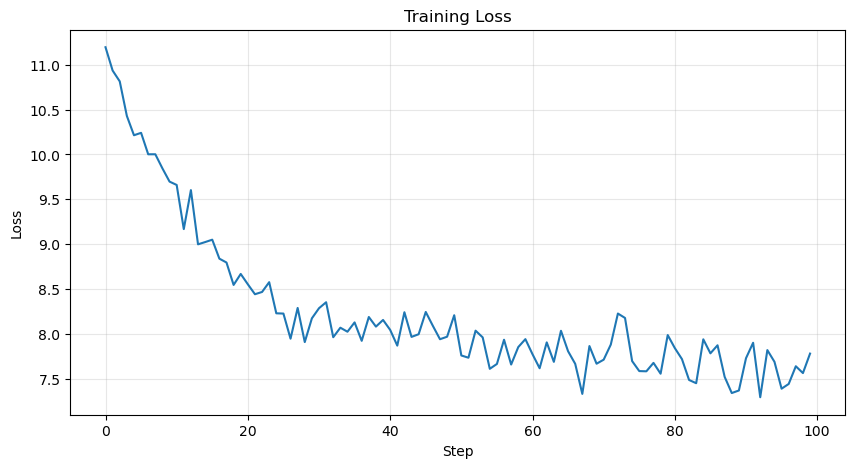


Initial loss: 11.1959
Final loss: 7.7799
Expected initial loss (log(vocab_size)): 10.8249


In [20]:
import matplotlib.pyplot as plt

small_model.train()
optimizer = torch.optim.Adam(small_model.parameters(), lr=1e-3)

num_steps = 100
vocab_size = tokenizer.vocab_size

losses = []
# here iter(train_loader) creates an iterator from the DataLoader, which allows us to use next() to get batches of data in a loop.
train_iter = iter(train_loader)


for step in range(num_steps):

    # 1. Get the next batch from the DataLoader:
    #    Move tokens and attention_mask to DEVICE
    # 2. Split the batch into input (all tokens in the sequence but the last token) and target (all tokens in the sequence but the first token)
    #    Also shift the attention_mask the same way as input_ids (drop last position)
    # 3. Forward pass with causal_mask=True and attention_mask=input_attention_mask
    # 4. Compute cross-entropy loss:
    #    F.cross_entropy(...)
    #    Note: `ignore_index` look up the documentation of F.cross_entropy
    # 5. Call the backward pass (see notes above)
    # 6. Append loss.item() to losses list (for logging)


    # gets next batch from the data loader, tokens will be the token IDs and attention_mask will
    # indicate which positions are real tokens (1) and which are padding (0).

    try:
        tokens, attention_mask = next(train_iter)
    except StopIteration:
        train_iter = iter(train_loader)
        tokens, attention_mask = next(train_iter)

    tokens = tokens.to(DEVICE)
    attention_mask = attention_mask.to(DEVICE)

    # so imagine if we have a token sequence like [BOS, "The", "cat", "sat", "on", "the", "mat", EOS],
    # the input to the model will be [BOS, "The", "cat", "sat", "on", "the", "mat"]
    # and the target will be ["The", "cat", "sat", "on", "the", "mat", EOS].
    inputs = tokens[:, :-1]
    targets = tokens[:, 1:]
    attn_in = attention_mask[:, :-1]

    # logits here will have shape (batch_size, seq_length-1, vocab_size) because we are predicting the next token for each position in the input sequence.
    logits = small_model(inputs, causal_mask=True, attention_mask=attn_in)

    # compute our loss with cross_entropy:
    # For each position:

    # the model predicts a probability distribution over the vocabulary
    # the true target is the correct next token
    # cross-entropy penalizes the model if it gives low probability to the true token
    loss = F.cross_entropy(logits.reshape(-1, vocab_size),targets.reshape(-1),ignore_index=tokenizer.pad_token_id)

    # backpropagation step: we first zero the gradients,
    # then call backward() on the loss to compute gradients,
    # and finally call optimizer.step() to update the model parameters based on the computed gradients.
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    # we append loss.item() to the losses list to keep track of the training loss over time for logging and visualization purposes.
    losses.append(loss.item())

    if (step + 1) % 10 == 0:
        print(f"Step {step+1}/{num_steps}, Loss: {losses[-1]:.4f}")

# Plot the training loss
plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nInitial loss: {losses[0]:.4f}")
print(f"Final loss: {losses[-1]:.4f}")
print(f"Expected initial loss (log(vocab_size)): {math.log(tokenizer.vocab_size):.4f}")

Finally, we can implement a learning rate scheduler, this will include linear warmup and linear decay. 

In [22]:
# We can define a learning rate scheduler to adjust the learning rate during training.
# many people commonly use cosine decay with warmup for training transformers,
#  which means that the learning rate starts at 0, increases linearly to the base learning rate during the warmup phase, and then decays following a cosine schedule after the warmup phase.
# HOWEVER, we just implement a simple linear warmup and decay schedule here for simplicity.

def get_lr_multiplier(step, warmup_steps, total_steps):
    '''
    Return the learning rate multiplier for the given step (used as lr = base_lr * multiplier).
    - Warmup (step < warmup_steps): multiplier goes from 0 to 1.
    - Decay (step >= warmup_steps): multiplier goes from 1 to 0.
    Args:
        step (int): Current training step (0-indexed).
        warmup_steps (int): Number of warmup steps.
        total_steps (int): Total number of training steps.
    Returns:
        float: Multiplier in [0, 1].
    '''
    if warmup_steps > 0 and step < warmup_steps:
        return step / float(warmup_steps)
    else:
        decay_steps = max(1, total_steps - warmup_steps)
        progress = (step - warmup_steps) / float(decay_steps)
        return max(0.0, 1.0 - progress)

Step 50/500, Loss: 8.5334, LR: 0.000500
Step 100/500, Loss: 7.4924, LR: 0.000444
Step 150/500, Loss: 7.8031, LR: 0.000389
Step 200/500, Loss: 7.6616, LR: 0.000333
Step 250/500, Loss: 7.5032, LR: 0.000278
Step 300/500, Loss: 7.5609, LR: 0.000222
Step 350/500, Loss: 7.4056, LR: 0.000167
Step 400/500, Loss: 6.9619, LR: 0.000111
Step 450/500, Loss: 7.1797, LR: 0.000056
Step 500/500, Loss: 7.5017, LR: 0.000000


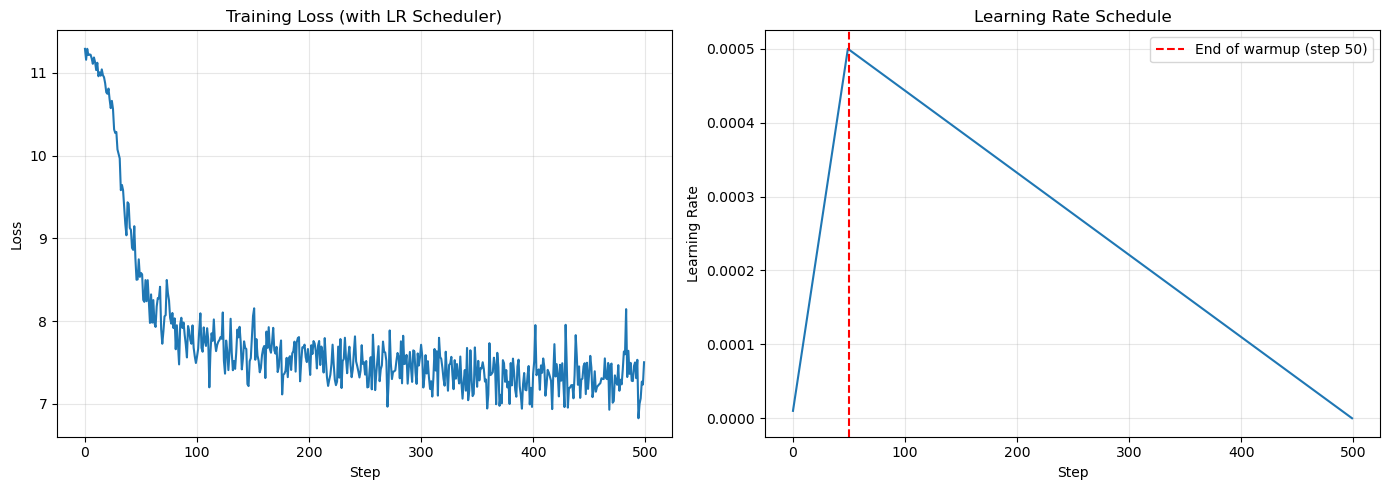


Initial loss: 11.2895
Final loss: 7.5017


In [23]:
# retrain with LR scheduler for longer
small_model_sched = TransformerModel(**small_config).to(DEVICE)
small_model_sched.train()

base_lr = 5e-4
num_steps_sched = 500
warmup_steps = 50

optimizer_sched = torch.optim.Adam(small_model_sched.parameters(), lr=base_lr)

# Create a LambdaLR scheduler using your get_lr_multiplier function
# Use torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=...)
# The lr_lambda should be a function that takes a step and returns the multiplier
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer_sched, lr_lambda=lambda s: get_lr_multiplier(s, warmup_steps, num_steps_sched))

losses_sched = []
lr_history = []
train_iter = iter(train_loader)

for step in range(num_steps_sched):
    try:
        tokens, attention_mask = next(train_iter)
    except StopIteration:
        train_iter = iter(train_loader)
        tokens, attention_mask = next(train_iter)
    tokens = tokens.to(DEVICE)
    attention_mask = attention_mask.to(DEVICE)

    input_ids = tokens[:, :-1]
    target_ids = tokens[:, 1:]
    input_attention_mask = attention_mask[:, :-1]

    logits = small_model_sched(input_ids, causal_mask=True, attention_mask=input_attention_mask)
    loss = F.cross_entropy(logits.view(-1, tokenizer.vocab_size), target_ids.reshape(-1), ignore_index=tokenizer.pad_token_id)

    optimizer_sched.zero_grad()
    loss.backward()
    optimizer_sched.step()
    # THIS LINE IS IMPORTANT: we need to call scheduler.step() after optimizer.step() to update the learning rate according to our schedule at each training step.
    scheduler.step()

    losses_sched.append(loss.item())
    # we just add the current learning rate to lr_history for logging and visualization purposes.
    # optimizer_sched.param_groups[0]['lr'] gives us the current learning rate after the scheduler has updated it.
    lr_history.append(optimizer_sched.param_groups[0]['lr'])

    if (step + 1) % 50 == 0:
        print(f"Step {step+1}/{num_steps_sched}, Loss: {loss.item():.4f}, LR: {lr_history[-1]:.6f}")

# Plot the training loss and learning rate
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(losses_sched)
ax1.set_xlabel('Step')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss (with LR Scheduler)')
ax1.grid(True, alpha=0.3)

ax2.plot(lr_history)
ax2.axvline(x=warmup_steps, color='r', linestyle='--', label=f'End of warmup (step {warmup_steps})')
ax2.set_xlabel('Step')
ax2.set_ylabel('Learning Rate')
ax2.set_title('Learning Rate Schedule')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nInitial loss: {losses_sched[0]:.4f}")
print(f"Final loss: {losses_sched[-1]:.4f}")